# KBO TrackMan 팔각도 추정: 근거와 검증

## tl;dr
KBO 공식 신장 **602명**, 1군 TrackMan **1,189,400구**를 확인했습니다. MLB 투수 단위 분리 평가에서 신장 포함 보정 모델의 MAE는 **4.76°**, 신장 제외는 5.19°입니다. KBO **1,674개 투수–시즌** 추정값을 저장했습니다. **KBO에서 실측 검증한 결과는 아닙니다.**

## Context & Methods
[Savant 공식 정의](https://baseballsavant.mlb.com/leaderboard/pitcher-arm-angles)는 릴리즈 순간 어깨–공 선과 수평선의 정면 각도입니다. 0°는 수평, 90°는 수직입니다. 신장·릴리즈 위치는 어깨 위치를 완전히 결정하지 못합니다.

### Key Assumptions
- 원본 TrackMan 릴리즈 위치와 익스텐션은 m로 해석했습니다. 제조사의 좌표 datum 계약을 별도로 확보하지는 못했습니다.
- MLB 모델은 2020–2024의 **qualified 투수–시즌 평균**으로 학습하며, 전체 투수를 묶어서 fold를 분리합니다. 2차 다항 + 표준화 + Ridge alpha=10을 사전 지정했습니다.
- 익스텐션은 정면 각도 식에 직접 들어가지 않습니다. MLB 기준값의 대응 익스텐션이 없어 보정 회귀에는 넣지 않았으며, KBO에서 신장 대비 익스텐션을 진단값으로 남겼습니다.
- 투구별 어깨 위치 시나리오는 자유 가정이며 신뢰구간이 아닙니다. MLB 오류를 KBO 보장 오류로 쓰지 않습니다.

이 노트북은 저장된 근거를 다시 검증하는 읽기 전용 companion입니다. 전수 계산 코드는 `src/visualbaseball/trackman_arm_angle.py`, 보정·교차검증은 `src/visualbaseball/arm_angle_calibration.py`에 있습니다.

### 1. Setup and saved inputs

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/visualbaseball').is_dir())
sys.path.insert(0, str(ROOT / 'src'))
RESULTS = ROOT / 'analysis/arm_angle/results'
quality = json.loads((RESULTS / 'quality_report.json').read_text())
calibration = json.loads((RESULTS / 'calibration_report.json').read_text())
cv = pd.read_csv(RESULTS / 'mlb_cross_validation.csv', dtype={'pitcher': str})
kbo = pd.read_csv(RESULTS / 'kbo_calibrated_pitchers.csv')
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})


## Data
### 2. Verify input provenance and row accounting

In [2]:
from visualbaseball.trackman_arm_angle import digest
assert quality['raw_rows'] == sum(r['raw_rows'] for r in quality['sources'])
assert quality['major_pitches'] == sum(r['major_rows'] for r in quality['sources'])
assert quality['major_pitches'] == sum(quality['statuses'].values())
assert digest(ROOT / 'data/tracking/player_heights.csv') == quality['input_hashes']['heights']
assert digest(RESULTS / 'mlb_reference.csv') == calibration['input_hashes']['reference']
for source in quality['sources']:
    path = ROOT / f"data/tracking/raw/season={source['season']}/trackman_history.csv"
    assert digest(path, normalize_newlines=True) == source['source_sha256']
counts = pd.DataFrame(quality['sources'])[['season','raw_rows','major_rows','excluded_non_major','unresolved_identity_rows']]
display(counts)


,season,raw_rows,major_rows,excluded_non_major,unresolved_identity_rows
0,2019,255957,188567,67390,29
1,2020,279126,202370,76756,0
2,2021,301032,202887,98145,43
3,2022,307637,194804,112833,4
4,2023,315100,199655,115445,0
5,2024,334226,201117,133109,0


### 3. Verify complete held-out predictions and reported errors

In [3]:
assert len(cv) == calibration['reference_rows']
assert not cv.duplicated(['pitcher','season']).any()
assert cv.groupby('pitcher').held_out_fold.nunique().eq(1).all()
assert cv.oof_prediction_deg.notna().all()
assert all(f['pitcher_overlap'] == 0 for f in calibration['folds'])
actual_mae = float((cv.oof_prediction_deg-cv.arm_angle).abs().mean())
assert np.isclose(actual_mae, calibration['model_oof']['mae_deg'])
assert kbo.mlb_calibrated_season_angle_deg.notna().sum() == calibration['kbo_season_estimates']
assert kbo.loc[kbo.outside_training_feature_range, 'mlb_calibrated_season_angle_deg'].isna().all()
methods = {
 'MLB model + height': 'model_oof', 'MLB model without height': 'without_height_oof',
 'Fixed 130 cm shoulder': 'fixed_130cm_baseline', 'Assumed height ratios': 'height_scenario_baseline'}
comparison = pd.DataFrame([{'method': name, **calibration[key]} for name,key in methods.items()])
display(comparison[['method','n','mae_deg','rmse_deg','bias_deg']].round(2))


,method,n,mae_deg,rmse_deg,bias_deg
0,MLB model + height,1295,4.76,6.02,-0.00
1,MLB model without height,1295,5.19,6.50,-0.00
2,Fixed 130 cm shoulder,1295,7.80,10.00,1.30
3,Assumed height ratios,1295,12.32,15.99,8.54


## Results
### 4. Compare the error of the four methods
출처: `results/calibration_report.json`, MLB 공식 1,295개 투수–시즌 관측값. 가로축은 평균 절대오차(도)이며 낮을수록 좋습니다.

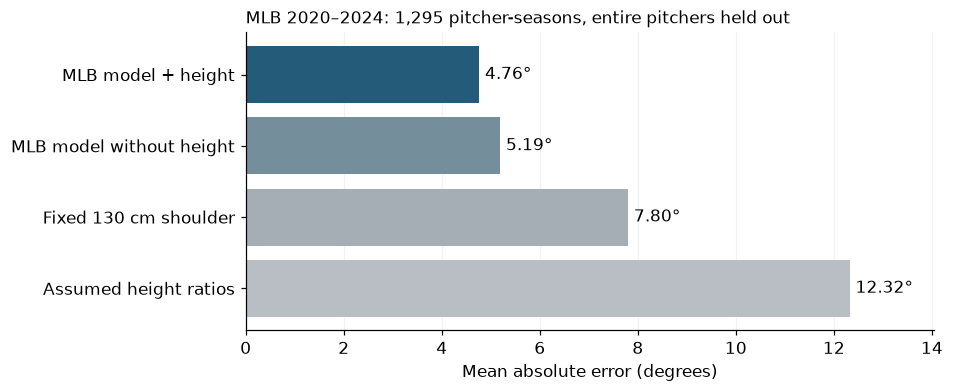

In [4]:
fig, ax = plt.subplots(figsize=(8.8, 3.7))
values = comparison.mae_deg.to_numpy()
ax.barh(comparison.method, values, color=['#245b78','#748e9c','#a4aeb4','#b8bec3'])
ax.invert_yaxis()
for i, value in enumerate(values):
    ax.text(value+.12, i, f'{value:.2f}°', va='center')
ax.set_xlim(0, max(values)*1.14)
ax.set_xlabel('Mean absolute error (degrees)')
ax.set_title('MLB 2020–2024: 1,295 pitcher-seasons, entire pitchers held out', loc='left', fontsize=11)
ax.grid(axis='x', alpha=.15); ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(RESULTS / 'mlb_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

신장 포함 모델이 신장 제외 모델보다 MAE 0.43° 낮았습니다. 투수 단위 paired cluster bootstrap 95% 개선 구간은 0.24–0.63°입니다. 임의 신장 비율 시나리오는 검증된 어깨 위치 모델이 아니므로 오히려 오차가 커졌습니다.

### 5. Check the spread of actual versus held-out predicted angles
출처: `results/mlb_cross_validation.csv`. 각 점은 투수–시즌입니다. 대각선은 예측과 실제 각도가 같은 위치입니다.

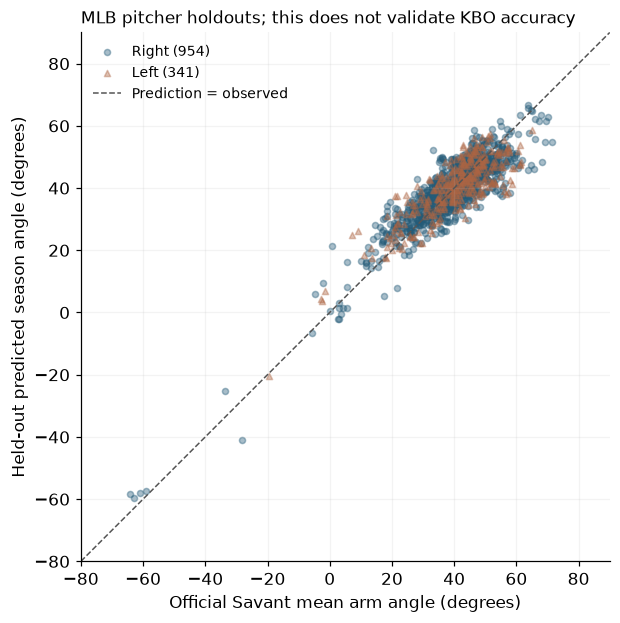

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 5.8))
for hand, marker, color in [('Right','o','#245b78'), ('Left','^','#ad6543')]:
    rows = cv[cv.pitcher_hand == hand]
    ax.scatter(rows.arm_angle, rows.oof_prediction_deg, s=16, alpha=.40, marker=marker, color=color, label=f'{hand} ({len(rows)})')
ax.plot([-80,90], [-80,90], color='#555555', linestyle='--', linewidth=1, label='Prediction = observed')
ax.set_xlim(-80,90); ax.set_ylim(-80,90); ax.set_aspect('equal')
ax.set_xlabel('Official Savant mean arm angle (degrees)')
ax.set_ylabel('Held-out predicted season angle (degrees)')
ax.set_title('MLB pitcher holdouts; this does not validate KBO accuracy', loc='left', fontsize=11)
ax.grid(alpha=.15); ax.legend(frameon=False, fontsize=9, loc='upper left')
fig.tight_layout()
fig.savefig(RESULTS / 'mlb_observed_predicted.png', dpi=160, bbox_inches='tight')
plt.show()


극단적인 슬롯에서는 오차가 증가합니다. 낮은 슬롯 MAE는 7.00°, 높은 슬롯은 9.48°입니다. 언더핸드는 13개, 높은 슬롯은 28개 투수–시즌뿐이므로 전체 평균 4.76°를 일률적인 정확도 보장으로 쓰면 안 됩니다.

### 6. Review KBO estimates and gaps
아래 KBO 결과는 **MLB에서 전이한 추정값**이며 실측값이 아닙니다. 소표본 시즌과 학습 범위 밖 기록은 상태를 함께 확인합니다.

In [6]:
names = ['박명근','정우영','유영찬','임찬규','김진성','김윤식']
selected = kbo[(kbo.season == 2024) & kbo.player_name.isin(names)]
display(selected[['player_name','height_cm','n_release_pitches','mlb_calibrated_season_angle_deg','transfer_status']].round(2))
display(kbo.transfer_status.value_counts().rename_axis('status').to_frame('pitcher_seasons'))
display(pd.read_csv(RESULTS / 'missing_heights.csv', dtype={'player_id': str}))


,player_name,height_cm,n_release_pitches,mlb_calibrated_season_angle_deg,transfer_status
1393,유영찬,185.0,1147,40.79,MLB_transfer_unvalidated_KBO
1395,김윤식,181.0,60,45.22,small_sample_unvalidated_KBO
1449,박명근,174.0,439,9.78,MLB_transfer_unvalidated_KBO
1504,임찬규,185.0,2392,42.54,MLB_transfer_unvalidated_KBO
1639,정우영,193.0,410,-2.83,MLB_transfer_unvalidated_KBO
1662,김진성,186.0,1161,61.74,MLB_transfer_unvalidated_KBO


,pitcher_seasons
status,
MLB_transfer_unvalidated_KBO,1361
small_sample_unvalidated_KBO,313
outside_MLB_training_range,4


,player_id,player_name,height_cm,candidate_source_url
0,76430,김상수,NaN,https://www.koreabaseball.com/Record/Player/Pi...
1,50205,박웅,NaN,https://www.koreabaseball.com/Record/Player/Pi...


## Takeaways
- 신장은 보정 모델에서 도움이 됐지만, 팔각도를 유일하게 결정하는 입력은 아닙니다. 익스텐션 역시 팔 길이가 아닙니다.
- 공식 신장을 사용한 MLB 보정 추정은 연구용 KBO 시즌 평균 지표입니다. 투구별 기하 시나리오와 분리해서 읽어야 합니다.
- 박웅/김상수의 현재 KBO 프로필 이름이 다르므로 두 신장은 사용하지 않았습니다. 미해결 선수 연결도 임의로 채우지 않았습니다.
- 다음 실제 검증은 KBO 영상에서 릴리즈 순간의 어깨와 공 위치를 측정하는 것입니다. 특히 낮은 슬롯과 높은 슬롯을 우선 비교하면 좋습니다.
- 초기 TrackMan 연구에서는 원본, canonical 데이터, 기존 웹 지표를 수정하지 않았습니다. 후속 Pitch Plot 구현은 `eaa-definition.md`를 참조하세요. 자세한 계산·재실행 방법과 한계는 같은 폴더의 README를 참조하세요.

## VB bridge, reference ranges and Y2Y
이번 후속 연구는 공식 신장을 134명 추가 확인하고 VB를 TM 좌표로 연결했다. **초기 전체 MLB 재학습 모델과 구분되는 고정 eAA 모델**을 사용한다. 학습/범위 보정/테스트는 전체 투수 단위로 분리했다. 아래 TM 비교값은 실측 KBO 팔각도가 아니라 같은 MLB 모델이 예측한 eAA다.

광주 등 미관측 구장에서는 구장 홀드아웃의 낮은 포함률 때문에 유한한 전체 참고 범위를 표시하지 않는다. 알려진 구장에 제공하는 반경 합도 KBO 신뢰구간이 아니다. 상세 정의는 `eaa-definition.md`에 있다.

In [7]:
bridge_report = json.loads((RESULTS / 'eaa_bridge_report.json').read_text())
eaa = pd.read_csv(RESULTS / 'eaa_vb_pitcher_seasons_2022_2026.csv', dtype={'pitcher_id':str})
bridge_cv = pd.read_csv(RESULTS / 'eaa_bridge_validation.csv', dtype={'pitcher_id':str})
ref_split = pd.read_csv(RESULTS / 'eaa_mlb_split_validation.csv', dtype={'pitcher':str})
y2y = pd.read_csv(RESULTS / 'eaa_vb_y2y_2022_2026.csv', dtype={'pitcher_id':str})
assert ref_split.groupby('pitcher')['split'].nunique().eq(1).all()
assert digest(ROOT / 'data/tracking/player_heights.csv') == bridge_report['input_hashes']['heights']
assert digest(ROOT / 'src/visualbaseball/vb_arm_angle.py') == bridge_report['input_hashes']['implementation']
assert digest(RESULTS / 'mlb_reference.csv') == bridge_report['input_hashes']['reference']
assert not eaa.duplicated(['season','pitcher_id','pitcher_hand']).any()
assert eaa.loc[eaa.estimate_status.ne('estimated_KBO_angle_unvalidated'), 'eaa_deg'].isna().all()
assert eaa.loc[eaa.unseen_stadium, ['reference_low_deg','reference_high_deg']].isna().all().all()
assert eaa.eaa_deg.notna().sum() == sum(v['estimated'] for y,v in bridge_report['outputs_by_year'].items() if int(y)>=2022)
cal_rows = bridge_cv[bridge_cv.evaluation.eq('bridge_calibration') & bridge_cv.n_pitches.ge(100)]
test_rows = bridge_cv[bridge_cv.evaluation.eq('pitcher_split_test') & bridge_cv.n_pitches.ge(100)]
assert not set(cal_rows.pitcher_id) & set(test_rows.pitcher_id)
from visualbaseball.vb_arm_angle import conformal_radius
radius, _ = conformal_radius(cal_rows.error_deg, cal_rows.pitcher_id)
assert np.isclose(radius, bridge_report['range_definition']['bridge_radius_deg'])
forward = bridge_cv[bridge_cv.evaluation.eq('forward_2024') & bridge_cv.n_pitches.ge(100)]
assert forward.season.eq(2024).all()
assert np.isclose(forward.error_deg.abs().mean(), bridge_report['VB_TM_bridge']['validation']['forward_2024']['season_eaa_vs_TM_model']['mae_deg'])
display(pd.DataFrame(bridge_report['outputs_by_year']).T[['pitcher_seasons','estimated']])
display(eaa.range_status.value_counts().to_frame('pitcher_seasons'))
display(pd.DataFrame([{'component': 'MLB measured angle', **bridge_report['MLB_reference_model']['test_metrics']},
                      {'component': 'VB vs TM-model eAA (2024)', **bridge_report['VB_TM_bridge']['validation']['forward_2024']['season_eaa_vs_TM_model']}]).round(3))

,pitcher_seasons,estimated
2019,252,203
2020,281,230
2021,305,249
2022,278,228
2023,284,231
2024,289,245
2025,280,231
2026,293,243


,pitcher_seasons
range_status,
unavailable_unseen_stadium_bias,956
withheld_estimate,246
reference_only_KBO_angle_unvalidated,173
reference_only_future_season_unvalidated,49


,component,n,mae_deg,rmse_deg,bias_deg,abs_error_p90_deg
0,MLB measured angle,267,4.426,5.586,0.621,8.792
1,VB vs TM-model eAA (2024),238,0.702,0.924,0.075,1.385


### Leave an entire stadium out
출처 / Source: `results/eaa_bridge_report.json`. Bars show absolute differences from **TM-model eAA**, not KBO measured-angle accuracy. The dotted line is the known-park bridge reference radius; it is not a success threshold for MAE. Poor holdout coverage is reported separately below.

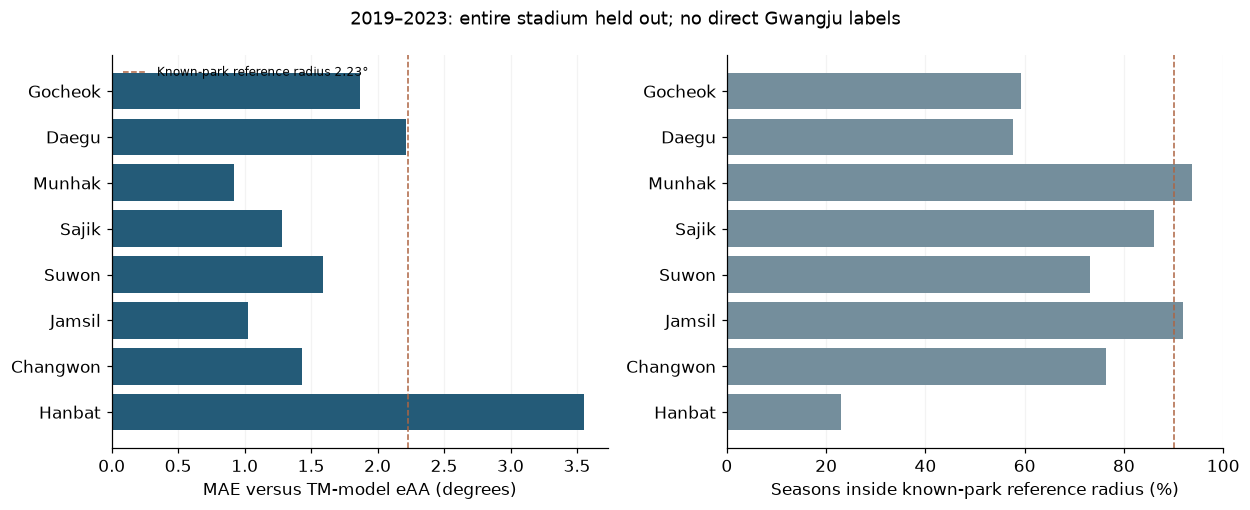

,stadium,mae_deg,coverage
0,고척,1.870,0.593
1,대구,2.216,0.576
2,문학,0.922,0.937
3,사직,1.283,0.861
4,수원,1.586,0.732
5,잠실,1.028,0.919
6,창원,1.435,0.763
7,한밭,3.556,0.230


In [8]:
park_eval = bridge_report['VB_TM_bridge']['validation']['leave_stadium_out']
park_order = ['고척','대구','문학','사직','수원','잠실','창원','한밭']
park_labels = ['Gocheok','Daegu','Munhak','Sajik','Suwon','Jamsil','Changwon','Hanbat']
park_table = pd.DataFrame([{'stadium': name, 'mae_deg': park_eval[name]['season_eaa_vs_TM_model']['mae_deg'],
                           'coverage': park_eval[name]['bridge_reference_coverage_seasons']} for name in park_order])
fig, (ax, bx) = plt.subplots(1,2,figsize=(11.5,4.7))
ax.barh(park_labels, park_table.mae_deg, color='#245b78')
ax.axvline(radius,color='#ad6543',linestyle='--',linewidth=1,label=f'Known-park reference radius {radius:.2f}°')
ax.set_xlabel('MAE versus TM-model eAA (degrees)'); ax.invert_yaxis(); ax.legend(fontsize=8,frameon=False)
bx.barh(park_labels,100*park_table.coverage,color='#748e9c')
bx.axvline(90,color='#ad6543',linestyle='--',linewidth=1)
bx.set_xlim(0,100); bx.set_xlabel('Seasons inside known-park reference radius (%)'); bx.invert_yaxis()
for axis in (ax,bx): axis.grid(axis='x',alpha=.15); axis.set_axisbelow(True)
fig.suptitle('2019–2023: entire stadium held out; no direct Gwangju labels',fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS / 'eaa_stadium_holdout.png',dpi=160,bbox_inches='tight')
plt.show()
display(park_table.round(3))

### Source-plane change and Y2Y
2026는 같은 55ft로 정규화했다. 동일 투수·구장·구종 전후 차이는 장비 변화와 실제 변화가 혼재한 기술 통계다. 시즌 평균을 강제로 같게 만들지 않았다. Y2Y의 공통 구장 비교는 구장 구성만 표준화하며, 실제 동작 변화 방향이나 KBO 오차범위 포함률을 증명하지 않는다.

In [9]:
display(pd.Series(bridge_report['source_plane_transition']).to_frame('value'))
display(y2y.status.value_counts().to_frame('year_pairs'))
assert y2y.loc[y2y.status.eq('withheld_missing_season_estimate'),'raw_change_deg'].isna().all()
assert y2y.loc[y2y.status.eq('direction_unresolved_unseen_stadium_range_unavailable'),'change_reference_low_deg'].isna().all()
examples = eaa[(eaa.season == 2026) & eaa.pitcher_name.isin(['유영찬','임찬규','김진성'])]
display(examples[['pitcher_name','height_cm','n_pitches','eaa_deg','reference_low_deg','reference_high_deg','range_status']].round(2))
print('Model reference radii (not KBO confidence intervals):', bridge_report['range_definition'])

,value
matched_pitcher_park_pitchtype_strata,419
median_x55_shift_cm,-0.81656
median_z55_shift_cm,0.128918
interpretation,within pitcher/park/pitch-type BEFORE vs AFTER...


,year_pairs
status,
direction_unresolved_unseen_stadium_range_unavailable,606
withheld_missing_season_estimate,153
direction_unresolved_by_reference_envelope,21


,pitcher_name,height_cm,n_pitches,eaa_deg,reference_low_deg,reference_high_deg,range_status
1133,유영찬,185.0,182,37.31,23.08,51.54,reference_only_future_season_unvalidated
1312,임찬규,185.0,2552,40.69,NaN,NaN,unavailable_unseen_stadium_bias
1416,김진성,186.0,840,59.71,NaN,NaN,unavailable_unseen_stadium_bias


Model reference radii (not KBO confidence intervals): {'kind': 'reference_envelope_NOT_KBO_prediction_interval', 'mlb_radius_deg': 11.99713185164767, 'bridge_radius_deg': 2.231163595390875, 'total_radius_deg': 14.228295447038544, 'nominal_component_coverage': 0.9, 'joint_coverage': 'unknown in KBO; if both components have 90pct coverage in the same target population, union bound gives a lower bound of 80pct, not 90pct; those conditions are not established in KBO', 'small_sample': 'withhold seasonal eAA below 100 valid pitches', 'domain': "withhold seasonal mean outside either model's marginal feature bounds; bounds do not certify joint support", 'unseen_stadium': 'point estimate flagged, finite reference envelope suppressed: park holdouts failed known-park radius; no Gwangju reference labels', 'future_season': 'flag for 2025–2026; no contemporaneous TM truth'}
